from PIL import Image, ImageOps, ImageEnhance
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

# Загружаем картинку
img = Image.open("flowers/flowers/19_010.png")

🔹 1. Поворот (Rotate)
rotated = rotate(img, 30, reshape=False)  # на 30°
plt.imshow(rotated); plt.axis("off"); plt.show()
👉 Модель учится распознавать объект под разными углами.

🔹 2. Отражения (Flip / Mirror)
flipped_h = ImageOps.mirror(img)  # горизонталь
flipped_v = ImageOps.flip(img)    # вертикаль
👉 Полезно, когда ориентация объекта может меняться.

🔹 3. Resize (просто растянуть/сжать)
resized = img.resize((150,150))
👉 Обычно используют для приведения всех картинок к одному размеру.

🔹 4. Crop + Resize (настоящий Zoom)
def zoom_image(image, scale=1.2):
    w, h = image.size
    new_w, new_h = int(w/scale), int(h/scale)
    left, top = (w-new_w)//2, (h-new_h)//2
    right, bottom = left+new_w, top+new_h
    cropped = image.crop((left, top, right, bottom))
    return cropped.resize((w,h))

zoomed = zoom_image(img, 1.2)
👉 Модель видит объект ближе (часть информации теряется, края обрезаны).

🔹 5. Изменение яркости / контраста
bright = ImageEnhance.Brightness(img).enhance(1.5)  # ярче
contrast = ImageEnhance.Contrast(img).enhance(0.7)  # менее контрастное
👉 Помогает модели не зависеть от освещения.

🔹 6. Изменение цвета (Color jitter)
color = ImageEnhance.Color(img).enhance(2.0)   # насыщеннее
👉 Учимся работать с разными цветовыми условиями.

🔹 7. Добавление шума (Noise)
import numpy as np
import random

def add_noise(image):
    arr = np.array(image)
    noise = np.random.randint(0,50, arr.shape, dtype="uint8")
    noisy = np.clip(arr + noise, 0, 255)
    return Image.fromarray(noisy)

noisy_img = add_noise(img)
👉 Модель становится устойчивее к «грязным» данным (камера, датчики).

🔹 8. Преобразование в ч/б (Grayscale)
gray = ImageOps.grayscale(img)
👉 Иногда помогает модели абстрагироваться от цвета и сосредоточиться на формах.

🔹 9. Обрезка (Random Crop)
cropped = img.crop((20, 20, 150, 150))  # (left, top, right, bottom)
👉 Модель учится видеть объект даже в неполном кадре.

🔹 10. Комбинация трансформаций
Можно применять цепочку:

aug = ImageOps.mirror(img)              # отразить
aug = ImageEnhance.Brightness(aug).enhance(0.8)  # затемнить
aug = zoom_image(aug, 1.3)              # приблизить

✨ Итог
📌 Основные аугментации, которые реально полезны:

rotate → повороты

mirror/flip → отражения

crop+resize (zoom) → приближения

brightness/contrast/color → свет и цвет

noise → «грязные данные»

grayscale → формы вместо цветов

Эти операции помогают увеличить разнообразие датасета и делают модель устойчивее к реальным условиям.

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d olgabelitskaya/flower-color-images

Dataset URL: https://www.kaggle.com/datasets/olgabelitskaya/flower-color-images
License(s): other
  0% 0.00/50.1M [00:00<?, ?B/s]
100% 50.1M/50.1M [00:00<00:00, 1.04GB/s]


In [5]:
!unzip flower-color-images.zip

Archive:  flower-color-images.zip
  inflating: FlowerColorImages.h5    
  inflating: flower_images/flower_images/0001.png  
  inflating: flower_images/flower_images/0002.png  
  inflating: flower_images/flower_images/0003.png  
  inflating: flower_images/flower_images/0004.png  
  inflating: flower_images/flower_images/0005.png  
  inflating: flower_images/flower_images/0006.png  
  inflating: flower_images/flower_images/0007.png  
  inflating: flower_images/flower_images/0008.png  
  inflating: flower_images/flower_images/0009.png  
  inflating: flower_images/flower_images/0010.png  
  inflating: flower_images/flower_images/0011.png  
  inflating: flower_images/flower_images/0012.png  
  inflating: flower_images/flower_images/0013.png  
  inflating: flower_images/flower_images/0014.png  
  inflating: flower_images/flower_images/0015.png  
  inflating: flower_images/flower_images/0016.png  
  inflating: flower_images/flower_images/0017.png  
  inflating: flower_images/flower_images/001

In [6]:
!pip install tensorflow
!pip install keras
!pip install pillow

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

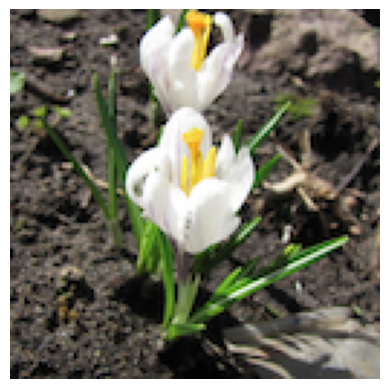

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = 'flowers/flowers/19_010.png'   # путь к файлу (одна из картинок)
original_image = Image.open(image_path)     # открыть картинку

plt.imshow(original_image)  # показать
plt.axis("off")             # убрать оси
#plt.show()

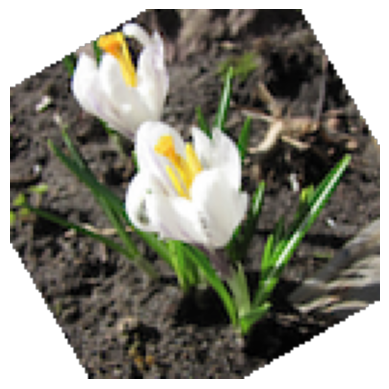

In [14]:
from scipy.ndimage import rotate

def rotate_image_30_degrees(image):
    return rotate(image, 30, reshape=False)

rotated = rotate_image_30_degrees(original_image)

plt.imshow(rotated)
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

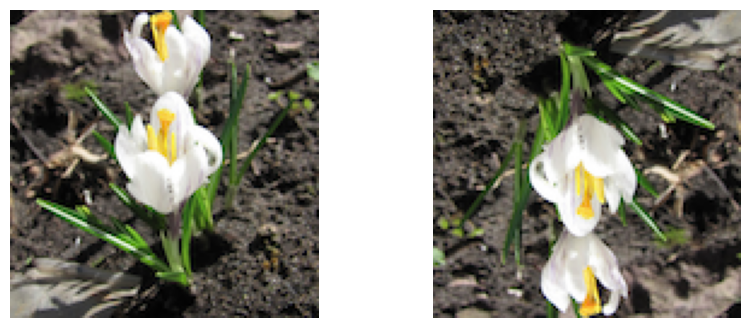

In [18]:
from PIL import ImageOps

# горизонтальное отражение (зеркало слева направо)
flipped_h = ImageOps.mirror(original_image)

# вертикальное отражение (переворот сверху вниз)
flipped_v = ImageOps.flip(original_image)

# покажем обе. создаём «холст» для картинок.
plt.figure(figsize=(10,4))

# говорим: «будет сетка из 1 строки × 2 колонок, и сейчас мы рисуем в первом окошке»
plt.subplot(1,2,1)
#plt.title("Горизонтально")
plt.imshow(flipped_h)
plt.axis("off")

plt.subplot(1,2,2)
#plt.title("Вертикально")
plt.imshow(flipped_v)
plt.axis("off")

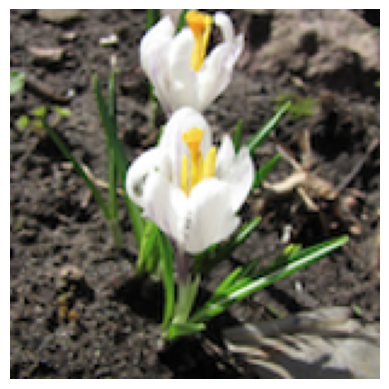

In [19]:
w, h = original_image.size

# увеличиваем размеры на 20% (×1.2)
zoomed = original_image.resize((int(w*1.2), int(h*1.2)))

# показываем результат
plt.imshow(zoomed)
plt.axis("off")
plt.show()

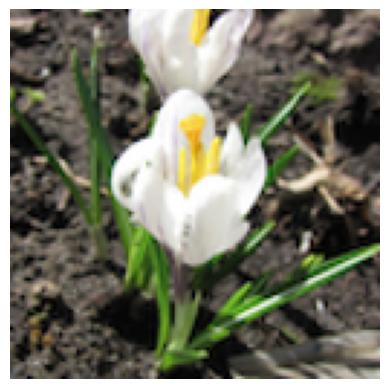

In [21]:
from PIL import Image

def zoom_image(image, scale):
    w, h = image.size

    # на сколько обрезать (разница между размерами)
    new_w = int(w / scale)
    new_h = int(h / scale)

    # координаты центра
    left = (w - new_w) // 2
    top = (h - new_h) // 2
    right = left + new_w
    bottom = top + new_h

    # вырезаем центральный кусок и растягиваем до исходного размера
    cropped = image.crop((left, top, right, bottom))
    return cropped.resize((w, h))

# применяем
zoomed_real = zoom_image(original_image, 1.2)

plt.imshow(zoomed_real)
plt.axis("off")
plt.show()

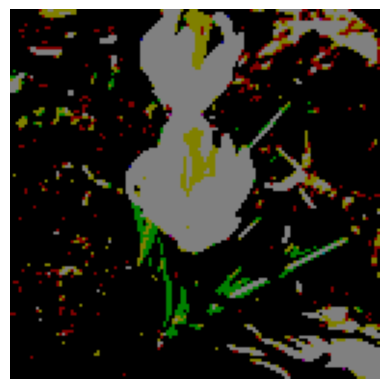

In [27]:
rgb_image = original_image.convert("RGB")
posterize_image=ImageOps.posterize(rgb_image, 1)
plt.imshow(posterize_image)
plt.axis("off")
plt.show()